In [45]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import torchvision.transforms as transforms
import torchvision.utils as vutils 
from torchvision.datasets import ImageFolder
from torchvision.datasets import CIFAR10
import torchvision.models as models
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import gc
import os

device  = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Plotting losses and accuracy for each epoch
def plot_results(log_lst, logs_name ,title, xlabel, ylabel):

    if len(logs_name) != len(log_lst):
        raise ValueError('logs_name and log_lst should have same length')
    
    x = np.arange(1, len(log_lst[0])+1) # x values starting from 1
    
    for logs, logs_name in zip(log_lst, logs_name):
        plt.plot(x,logs, label=logs_name, marker='o', markersize=3)
    
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()

In [46]:
import torch
import numpy as np

#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Mon Jun 26 17:11:36 2023
This code was written by Dr. Ahmad Kalhor (ad.kalhor@gmail.com)in pytorch framework
It includes "Kalhor_SeparationIndex" class with 24 methods.
"""

import torch
import numpy as np

# ===========Some notes about the class
# All methods of the class are developed from the concept of Separation Index(SI).
# SI is a normalized supervised data complexity measure which is utilised to analyze and design AI-models in classification problems.
# Each method actually measures a variant  separability of the data points of different classes with each other.
# The functionality of each method have been explained where they are defined in the body of the class.
# To illustrate  how one can use this class, three different examples are provided in three different executable files.

# ==========Some applications of using "Kalhor_SeparationIndex" class:
# 1-To evaluate different datasets (datasets with lower SI (SI--->0) are more challenging than those with high SI (SI--->1))
# 2-To evaluate different layers of a shallow/deep classification model(it is expected that in an appropriate learned model, SI increases (in average) to one layer by layer)
# 3-To rank different models (models which provide higher SIs are more appropriate)
# 4-To check the generalization of a model( models with higher cross-SI have more generalization)
# 5-To rank different features and select the best subset in a classification problem(features which makes higher SI are better)
# 6-To clean datasets or models which are poisoned/attacked by backdoors/trojans/biases (SI can detect such issues and remove them)
# 7-To Compress a classification model (layers and nodes which can not increase the SI are removed)
# 8-To learn a model in a forward layer-wise manner (using a ranking loss (to maximize the SI) at each layer, one can get better results than conventional backpropagation methods)
# 9-To find some key layers and nodes where a model makes some branches or being fused by other models in order to maximize the SI.
# 10-To determine a trustworthy/confidence/guarantee for the predictions of the model (High order (or soft order) SIs are utilized) .
# 11-To remove risky data points and augment new effective data points for better training and generalization.

# ===Start of the class=================================================================================================
# ==========body of the class=====================================================================
class Kalhor_SeparationIndex:
    # this class makes an object by receiving two arguments: "data" and "label" as a classification dataset (with n_class categories)
    # "data" is a (n_data*n_feature) tensor as input feature pints matrix(n_data  denotes the number of data inputs and n_feature denotes the number of features)
    # "label" is (n_data*1) tensor as label matrix(labels includes integer numbers between "label_min" to "n_class-label_min+1" )
    # One can normalize features of the data matrix by inserting "normalize=True" in the the argument of the object ("normalize=False" is default state)
    def __init__(self, data, label, normalize=False):
        # device1 = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        self.normalize=normalize
        if not normalize:
            self.data = data
        else:
            small_number = 1e-10
            mean_data = data.mean(0)
            std_data = data.std(0) + small_number
            data = (data - mean_data.reshape([1, -1]).repeat(data.shape[0], 1)) / std_data.reshape([1, -1]).repeat \
                (data.shape[0], 1)
            self.data = data
            self.std_data=std_data
            self.mean_data=mean_data
            print('data becomes normalized')
        self.device1 = self.data.device
        self.label_min = round(torch.min(label).detach().item())
        self.label = (label - self.label_min).to(self.device1)
        # "dis_matrix" denotes an "Euclidean" distance matrix where "kth" row denotes the distance of "kth" input data point with all n_data data points.
        self.big_number = 1e10
        self.dis_matrix = torch.cdist(self.data, self.data, p=2).fill_diagonal_(self.big_number)
        self.n_class = round(torch.max(self.label).detach().item()) + 1
        self.n_data = self.data.shape[0]
        self.n_feature = self.data.shape[1]

    # (1. si method )==========================================
    # This method measures the  separation index (si) of whole classes and  data points in a classification dataset.
    # This method counts all  data points having equal labels with their nearest neighbors(by distance) then divides it by n_data
    # "si" is a normalized score between 0 and 1.
    # For challenging datasets si is near to zero (minimum separation). A deep learning model is suggested for such datasets.
    # For easy datasets si is near to one(maximum separation). A shallow model is suggested for such datasets.
    def si(self):
        values, indices = torch.min(self.dis_matrix, 1)
        si_data = (self.label[indices, :] == self.label)
        si = torch.sum(si_data) / self.n_data
        return si

    # (2. si_class method)==========================================
    # This method measures separation index for all classes, independently, and gives "si-class" as a vector with n_class elements.
    # The "kth" element of "si_class" denotes the "si" of "kth" class versus other classes
    # For challenging classes si is near to zero (such class has overlap with other classes)
    # For easy classes si is near to one(such class is separated by other classes)
    def si_class(self):
        values, indices = torch.min(self.dis_matrix, 1)
        label_sort_neighb = self.label[indices, :].repeat(1, self.n_class)
        label_class = torch.arange(self.n_class, device=self.device1).repeat(self.n_data, 1)
        label_matrix = self.label.repeat(1, self.n_class)
        si_class = torch.sum((label_sort_neighb == label_class) * (label_matrix == label_class), 0) / torch.sum(
            (label_class == label_matrix), 0)
        return si_class

    # (3. si_data method)==========================================  si_data
    # This method measures separation index for each data point, independently and gives "si_data" as a vector with n_data elements.
    # The "ith" element of "si_data" denotes the "si" of "ith" data point which is "1" or "0"
    # For difficult data points si is "0"  and For easy data points si is "1"
    def si_data(self):
        values, indices = torch.min(self.dis_matrix, 1)
        si_data = (self.label[indices] == self.label).float()  # Use float() to get 0 and 1
        return si_data

    # (4. high_order_si method)==========================================
    # This method measures "rth" order of separation index (as high_si) for whole classes and data points in a classification dataset.
    # This method counts all data points having equal labels with all their first "order" nearest neighbors(by distance) then divides it by n_data
    # the resulted 'high_si' is a normalized score between 0 and 1.
    # high_si is a more restrict concept of separation and for we always have high_si<= si.
    # if for order>>1, high_si becomes near to one, it means that data points of each class are significantly far from other classes
    def high_order_si(self, order):
        dis_matrix_sort, arg_sort = torch.sort(self.dis_matrix, 1)
        label_matrix = self.label.repeat(1, order)
        label_sort_neighb = self.label[arg_sort[:, 0:order], :].reshape([self.n_data, order])
        comp_label = (label_matrix == label_sort_neighb) * 1
        high_si = comp_label.prod(1).sum() / self.n_data
        return high_si

    # (5. high_order_si_class method )==========================================
    # This method measures "rth" order of separation index for all classes, independently, and gives "high_si_class" as a vector with n_class elements.
    # The "kth" element of "high_si_class" denotes the "high_si" of "kth" class versus other classes
    # if for order>>1, "kth" element of high_si_class becomes near to one, it means that data points of "kth" class are significantly far from other classes
    def high_order_si_class(self, order):
        dis_matrix_sort, arg_sort = torch.sort(self.dis_matrix, 1)
        label_sort_neighb = self.label[arg_sort[:, 0:order], :].repeat([1, 1, self.n_class])
        label_class = torch.arange(self.n_class, device=self.device1).repeat([self.n_data, order, 1])
        label_matrix = self.label.reshape([-1, 1, 1]).repeat([1, order, 1]).repeat([1, 1, self.n_class])
        comp_label = (label_sort_neighb == label_class) * (label_matrix == label_class) * 1
        high_si_class = comp_label.prod(1).sum(0) / (label_class[:, 0, :] == label_matrix[:, 0, :]).sum(0).reshape(
            [1, -1])
        return high_si_class

    # (6. high_order_si_data method)=================================================
    # This method measures high_order separation index for each data point, independently and gives "high_si_data" as a vector with n_data elements.
    # The "ith" element of "high_si_data" denotes the "high_si" of "ith" data point which is "1" or "0"
    # For order>>1, data points with high_si=1 are far easy data points which are surrounded by many data points with the same label
    def high_order_si_data(self, order):
        dis_matrix_sort, arg_sort = torch.sort(self.dis_matrix, 1)
        label_matrix = self.label.repeat(1, order)
        label_sort_neib = self.label[arg_sort[:, 0:order], :].reshape([self.n_data, order])
        comp_label = (label_matrix == label_sort_neib) * 1
        high_si_data = comp_label.prod(1)
        return high_si_data

    # (7. anti_si method)==========================================
    # This method counts all data points having not equal labels with all their first "order" nearest neighbors(by distance) then divides it by n_data
    # The resulted 'anti_si' is a normalized score between 0 and 1.
    def anti_si(self, order):
        dis_matrix_sort, arg_sort = torch.sort(self.dis_matrix, 1)
        label_matrix = self.label.repeat(1, order)
        label_sort_neighb = self.label[arg_sort[:, 0:order], :].reshape([self.n_data, order])
        comp_label = 1 - (label_matrix == label_sort_neighb) * 1
        anti_si = comp_label.prod(1).sum() / self.n_data
        return anti_si

    # (8. anti_si_class method )==========================================
    # This method measures "rth" order of anti separation index for all classes, independently, and gives "anti_si_class" as a vector with n_class elements.
    # The "kth" element of "anti_si_class" denotes the "anti_si" of "kth" class versus other classes
    # if for order>>1, "kth" element of anti_si_class becomes near to one, it means that all data points of "kth" class are significantly far from each other and located among data points from other classes
    def anti_si_class(self, order):
        dis_matrix_sort, arg_sort = torch.sort(self.dis_matrix, 1)
        label_sort_neighb = self.label[arg_sort[:, 0:order], :].repeat([1, 1, self.n_class])
        label_class = torch.arange(self.n_class, device=self.device1).repeat([self.n_data, order, 1])
        label_matrix = self.label.reshape([-1, 1, 1]).repeat([1, order, 1]).repeat([1, 1, self.n_class])
        comp_label = (label_sort_neighb == label_class) * (label_matrix == label_class) * 1
        anti_si_class = comp_label.prod(1).sum(0) / (label_class[:, 0, :] == label_matrix[:, 0, :]).sum(0).reshape(
            [1, -1])
        return anti_si_class

    # (9. anti_si _data method)=================================================
    # This method measures anti_order separation index for each data point, independently and gives "anti_si_data" as a vector with n_data elements.
    # The "ith" element of "anti_si_data" denotes the "anti_si" of "ith" data point which is "1" or "0"
    # For order>>1, data points with "anti_si=1 are far difficult data points which are surrounded by many data points with not equal labels
    def anti_si_data(self, order):
        dis_matrix_sort, arg_sort = torch.sort(self.dis_matrix, 1)
        label_matrix = self.label.repeat(1, order)
        label_sort_neighb = self.label[arg_sort[:, 0:order], :].reshape([self.n_data, order])
        comp_label = 1 - (label_matrix == label_sort_neighb) * 1
        anti_si_data = comp_label.prod(1)
        return anti_si_data

    # (10. soft_order_si method)==========================================
    # This method measures "rth" order of soft separation index (as soft_si) for whole classes and data points in a classification dataset.
    # This method give a soft score to each data point with respect to their first "order" nearest neighbors(by distance) then divides sum of scores by n_data
    # If a data point has order1<=order neighbors with equal label from "order" nearest neighbors, then its soft score is equal to order1/order
    # the resulted 'soft_si' is a normalized score between 0 and 1.
    # soft_si is a less strict concept of separation and we always have soft_si<= high_si.
    def soft_order_si(self, order):
        dis_matrix_sort, arg_sort = torch.sort(self.dis_matrix, 1)
        label_matrix = self.label.repeat(1, order)
        label_sort_neighb = self.label[arg_sort[:, 0:order], :].reshape([self.n_data, order])
        comp_label = (label_matrix == label_sort_neighb) * 1
        soft_si = comp_label.sum(1).sum() / (self.n_data * order)
        return soft_si

    # (11. soft_order_si_class method)==========================================
    # This method gives a soft score to each data point with respect to their first "order" nearest neighbors(by distance) then divides sum of scores by n_data
    # If a data point,from its "order" nearest neighbors, has order_1<=order neighbors with equal label, then its soft score is equal to order_1/order
    # the resulted 'soft_si' is between 0 and 1.
    # soft_si is a less strict concept of separation, and we always have: soft_si<= high_si.

    def soft_order_si_class(self, order):
        dis_matrix_sort, arg_sort = torch.sort(self.dis_matrix, 1)
        label_sort_neighb = self.label[arg_sort[:, 0:order], :].repeat([1, 1, self.n_class])
        label_class = torch.arange(self.n_class, device=self.device1).repeat([self.n_data, order, 1])
        label_matrix = self.label.reshape([-1, 1, 1]).repeat([1, order, 1]).repeat([1, 1, self.n_class])
        comp_label = (label_sort_neighb == label_class) * (label_matrix == label_class) * 1
        soft_si_class = comp_label.sum(1).sum(0) / (
                order * (label_class[:, 0, :] == label_matrix[:, 0, :]).sum(0).reshape([1, -1]))
        return soft_si_class

    # (12. soft_order_si_data method)==========================================
    # This method gives a soft score to each data point with respect to their first "order" nearest neighbors(by distance) then divides sum of scores by n_data
    # If a data point,from its "order" nearest neighbors, has order1<=order neighbors with equal label, then its soft score is equal to r1/order
    # the resulted 'soft_si' is between 0 and 1.
    # soft_si is a less strict concept of separation, and we always have: soft_si<= high_si.
    def soft_order_si_data(self, order):
        dis_matrix_sort, arg_sort = torch.sort(self.dis_matrix, 1)
        label_matrix = self.label.repeat(1, order)
        label_sort_neighb = self.label[arg_sort[:, 0:order], :].reshape([self.n_data, order])
        comp_label = (label_matrix == label_sort_neighb) * 1
        soft_si_data = comp_label.sum(1) / order
        return soft_si_data

    # (13. center_si method)==========================================
    # This method measures the center based separation index (csi) of whole classes and  data points in a classification dataset.
    # This method counts all data points having equal labels with mean of all data points with the same label then divides it by n_data
    # "center_si" is computed much faster than other methods, and it is a normalized score between 0 and 1.
    # It is suggested to apply center-si instead of other methods for when the data points of a class make a simply connected region
    # For datasets where data points of each class makes a unique and normal distribution,center_si is near to one and is computed much faster than the original "si" method
    def center_si(self):
        label_feature_class = torch.arange(self.n_class, device=self.device1).repeat([self.n_data, self.n_feature, 1])
        label_feature_matrix = self.label.reshape([-1, 1, 1]).repeat([1, self.n_feature, 1]).repeat(
            [1, 1, self.n_class])
        label_comp = (label_feature_class == label_feature_matrix) * 1
        data_class = self.data.reshape([-1, self.n_feature, 1]).repeat([1, 1, self.n_class])
        data_class_center = ((data_class * label_comp).sum(0) / (label_comp).sum(0)).transpose(0, 1)
        dis_matrix = torch.cdist(self.data, data_class_center, p=2)
        values, label_neighb_center = torch.min(dis_matrix, 1)
        label_neighb_center = label_neighb_center.reshape([-1, 1])
        csi = torch.sum(label_neighb_center == self.label) / self.n_data
        return csi

    # (14. center_si_class method)==========================================
    # This method measures the center based separation index (csi_class) of each class, independently.
    # This method gives "csi_class" as a vector with n_class elements.
    # The "kth" element of "csi_class" denotes the "center_si" of "kth" class versus other classes
    # For challenging classes which has multi parted distributions, center_si is near to zero.
    # For easy classes which has a unique and normal distribution, center_si is near to one.
    def center_si_class(self):
        label_feature_class = torch.arange(self.n_class, device=self.device1).repeat([self.n_data, self.n_feature, 1])
        label_feature_matrix = self.label.reshape([-1, 1, 1]).repeat([1, self.n_feature, 1]).repeat(
            [1, 1, self.n_class])
        label_comp = (label_feature_class == label_feature_matrix) * 1
        data_class = self.data.reshape([-1, self.n_feature, 1]).repeat([1, 1, self.n_class])
        data_class_center = ((data_class * label_comp).sum(0) / (label_comp).sum(0)).transpose(0, 1)
        dis_matrix = torch.cdist(self.data, data_class_center, p=2)
        values, label_neighb_center = torch.min(dis_matrix, 1)
        label_neighb_center_class = label_neighb_center.reshape([-1, 1]).repeat(1, self.n_class)
        label_class = torch.arange(self.n_class, device=self.device1).repeat(self.n_data, 1)
        label_matrix = self.label.repeat(1, self.n_class)
        csi_class = torch.sum((label_neighb_center_class == label_class) * (label_matrix == label_class),
                              0) / torch.sum(
            (label_class == label_matrix), 0)

        return csi_class

    # (15. center_si_data method)==========================================
    # This method measures the center based separation index (csi_data) of each class, independently.
    # This method gives "csi_data" as a vector with n_data elements.
    # The "ith" element of "csi_data" denotes the "center_si" of "ith" data point
    # For each difficult data point csi_data=0 and for each easy data point csi_data=1.
    def center_si_data(self):
        label_feature_class = torch.arange(self.n_class, device=self.device1).repeat([self.n_data, self.n_feature, 1])
        label_feature_matrix = self.label.reshape([-1, 1, 1]).repeat([1, self.n_feature, 1]).repeat(
            [1, 1, self.n_class])
        label_comp = (label_feature_class == label_feature_matrix) * 1
        data_class = self.data.reshape([-1, self.n_feature, 1]).repeat([1, 1, self.n_class])
        data_class_center = ((data_class * label_comp).sum(0) / (label_comp).sum(0)).transpose(0, 1)
        dis_matrix = torch.cdist(self.data, data_class_center, p=2)
        values, label_neighb_center = torch.min(dis_matrix, 1)
        label_neighb_center = label_neighb_center.reshape([-1, 1])
        csi_data = (label_neighb_center == self.label) * 1

        return csi_data

    # (16. cross_si method)==========================================
    # This method measures how another domain of classification dataset (test data),which has equal data dimension and classes with our main classification problem, makes separability with our classification(train) dataset.
    # This method counts all test data points having equal labels with their nearest neighbors(by distance) from train dataset then divides it by n_test
    # "cross_si" is a normalized score between 0 and 1.
    # For when test dataset has far distribution with our train dataset cross_si is far less that si of our train dataset.
    # For when test dataset has near distribution with our train dataset cross_si is about si of our train dataset.
    def cross_si(self, data_test, label_test):
        if self.normalize:
            data_test = (data_test - self.mean_data.reshape([1, -1]).repeat(data_test.shape[0], 1)) / self.std_data.reshape([1, -1]).repeat \
                (data_test.shape[0], 1)
        label_test -= label_test.min()
        n_test, n_feature = data_test.shape
        cross_dis_matrix = torch.cdist(data_test, self.data, p=2)
        values, indices = torch.min(cross_dis_matrix, 1)
        cr_si_data = (self.label[indices, :] == label_test)
        cross_si = torch.sum(cr_si_data) / n_test
        return cross_si

    # (17. cross_si_class method)==========================================
    # This method measures how  classes from another domain of classification dataset (test data),which has equal data dimension and classes with our main classification problem, are independently separated with other classes from our classification(train) dataset.
    # This method gives a vector "cross_si_class" with n_class classes and "kth" element shows how "kth" class of test dataset  can be separated in our train.
    # Each class, which has cross_si far less than the si of the same class in our train dataset, is challenging to be predicted by the model which is learned by our train dataset.
    # Each class, which has cross_si near the si of the same class in our train dataset, is easy to be predicted by the model which is learned by our train dataset.

    def cross_si_class(self, data_test, label_test):
        if self.normalize:
            data_test = (data_test - self.mean_data.reshape([1, -1]).repeat(data_test.shape[0], 1)) / self.std_data.reshape([1, -1]).repeat \
                (data_test.shape[0], 1)


        label_test -= label_test.min()
        cross_dis_matrix = torch.cdist(data_test, self.data, p=2)
        values, indices = torch.min(cross_dis_matrix, 1)
        label_sort_neighb = self.label[indices, :].repeat(1, self.n_class)
        label_class = torch.arange(self.n_class, device=self.device1).repeat(data_test.shape[0], 1)
        label_matrix = label_test.repeat(1, self.n_class)
        cross_si_class = torch.sum((label_sort_neighb == label_class) * (label_matrix == label_class), 0) / torch.sum(
            (label_class == label_matrix), 0)
        return cross_si_class

    # (18. cross_si_data method)==========================================
    # This method measures how datapoints from another domain of classification dataset (test data),which has equal data dimension and classes with our main classification problem, are independently separated from datapoints with different labels in our classification(train) dataset.
    # This method gives a vector "cross_si_data" with n_test elements where "ith" element shows how "ith" element of the test dataset is separated in our train.
    # Each data point, which has cross_si_data=0 is challenging to be predicted by the model which is learned by our train dataset.
    # Each data point, which has cross_si_data=1 is easy to be predicted by the model which is learned by our train dataset.
    def cross_si_data(self, data_test, label_test):
        if  self.normalize:
            data_test = (data_test - self.mean_data.reshape([1, -1]).repeat(data_test.shape[0], 1)) / self.std_data.reshape([1, -1]).repeat \
                (data_test.shape[0], 1)
        cross_dis_matrix = torch.cdist(data_test, self.data, p=2)
        values, indices = torch.min(cross_dis_matrix, 1)
        cr_si_data = (self.label[indices, :] == label_test)
        return cr_si_data
    # This method assigns maximum order of si for each datapoint if it is positive;
    # otherwise it assigns the negative of maximum order of anti_si.
    # (19. data_score_si_anti_si method)==========================================
    def data_score_si_anti_si(self):
        dis_matrix_sort, arg_sort = torch.sort(self.dis_matrix, 1)
        label_matrix = self.label.repeat(1, self.n_data)
        label_sort_neighb = self.label[arg_sort, :].reshape([self.n_data, self.n_data])
        comp_label = (label_matrix == label_sort_neighb) * 1
        #
        arg_neg = comp_label.argmin(1)
        arg_pos = comp_label.argmax(1)
        data_score = (arg_pos == 0) * arg_neg-(arg_neg == 0) * (arg_pos)
        return data_score
    # This method assigns maximum order of si for  each test datapoint if it is positive;
    # otherwise it assigns the negative of maximum order of anti_si.
    # (20. cross_data_score_si_anti_si method)==========================================
    def cross_data_score_si_anti_si(self, data_test, label_test):
        if self.normalize:
            data_test = (data_test - self.mean_data.reshape([1, -1]).repeat(data_test.shape[0], 1)) / self.std_data.reshape([1, -1]).repeat \
            (data_test.shape[0], 1)
        label_test -= label_test.min()
        n_test, n_feature = data_test.shape
        cross_dis_matrix = torch.cdist(data_test, self.data, p=2)
        dis_matrix_sort, arg_sort = torch.sort(cross_dis_matrix, 1)
        label_matrix = label_test.repeat(1, self.n_data)
        label_sort_neighb = label_test[arg_sort,:].reshape([n_test, self.n_data])
        comp_label = (label_matrix == label_sort_neighb) * 1
        arg_neg = comp_label.argmin(1)
        arg_pos = comp_label.argmax(1)
        cross_data_score = (arg_pos == 0) * arg_neg-(arg_neg == 0) * (arg_pos)
        return cross_data_score

    # This method appriximately measures how rank of  datapoints distances (with nearest like and unlike labels) may have the same rank in their labels
    # (21. triplet_local_si method)==========================================
    def triplet_local_si(self):
        dis_matrix_sort, arg_sort = torch.sort(self.dis_matrix, 1)
        label_matrix = self.label.repeat(1, self.n_data)
        label_sort_neighb = self.label[arg_sort, :].reshape([self.n_data, self.n_data])
        comp_label = (label_matrix == label_sort_neighb) * 1
        #
        arg_neg = comp_label.argmin(1)
        arg_pos = comp_label.argmax(1)
        #
        inp_positive = self.data[arg_pos, :]
        inp_negative = self.data[arg_neg, :]
        #
        si_data = (self.label[arg_sort[:, 0], :] == self.label)
        si = torch.sum(si_data) / self.n_data
        return si, self.data, inp_positive, inp_negative

    # This method appriximately measures how rank of datapoints distances may have the same rank in their labels
    # (22. triplet_global_si method)
    def triplet_global_si(self):
        r2 = torch.randperm(self.n_data, device=self.device1)
        r3 = torch.randperm(self.n_data, device=self.device1)
        #
        diff_label = ((self.label == self.label[r2, :]) >= (self.label == self.label[r3, :]))
        diff_inp = (torch.pairwise_distance(self.data, self.data[r2, :]) <= torch.pairwise_distance(self.data,
                                                                                                    self.data[r3,
                                                                                                    :]))

        sort_label, arg_label = torch.sort(diff_label * 1)
        arg_part1 = arg_label[0:torch.argmax(sort_label)]
        arg_part2 = arg_label[torch.argmax(sort_label):]
        # data_ancher=self.data
        data_positive = self.data[torch.cat((r2[arg_part1], r3[arg_part2])), :]
        data_negative = self.data[torch.cat((r3[arg_part1], r2[arg_part2])), :]
        #
        g_si = ((diff_label == diff_inp) * 1.0).mean()
        return g_si, self.data, data_positive, data_negative

    # (23. data_dividing method_si)==========================================
    # this method receive si_data/high_si_data/center_si_data/cross_si_data and divide them as two difficult and easy datasets.\
    # Easy datasets are data points which their si/high_si/cross_si are one.
    # Difficult datasets are data points which their si/high_si/cross_si are zero.
    def data_dividing_si(self, si_data):
        n_data_easy = torch.sum(si_data)
        n_data_difficult = self.n_data - n_data_easy.detach()
        si_sort, arg_sort = torch.sort(si_data, 0)
        data_difficult = self.data[arg_sort[0:n_data_difficult, :], :]
        label_difficult = self.label[arg_sort[0:n_data_difficult, :]] + self.label_min
        data_easy = self.data[arg_sort[n_data_difficult:, 0], :]
        label_easy = self.label[arg_sort[n_data_difficult:, 0], 0] + self.label_min
        return data_difficult, label_difficult, data_easy, label_easy

    # (24. single_feature_si method)==========================================
    # This method computes the single_feature_si as a vector with n_feature elements
    # "kth" element of the vector independently shows the si of the "kth" feature of the data points.
    # The features which provide high si are more important for the classification model.
    # The features which provide less si are less important for the classification model.
    def single_feature_si(self):
        data_3d = self.data.reshape([-1, 1, self.n_feature]).repeat([1, self.n_data, 1])
        tr_data_3d = data_3d.transpose(0, 1)
        distanc_3d = data_3d ** 2
        tr_distanc_3d = distanc_3d.transpose(0, 1)
        eye_3d = torch.eye(self.n_data, device=self.device1).reshape([self.n_data, self.n_data, 1]).repeat(
            [1, 1, self.n_feature])
        dis_matrix_features = eye_3d * self.big_number + distanc_3d + tr_distanc_3d - 2 * (data_3d * tr_data_3d)
        values, indices = dis_matrix_features.min(1)
        #
        label_star = self.label[indices]
        label_star = label_star[:, :, 0]
        label_2d = self.label.reshape([-1, 1]).repeat([1, n_feature])
        single_feature_si = torch.sum(label_2d == label_star, 0) / self.n_data
        return single_feature_si

    # (25. forward_feature_ranking_si method)==========================================
    # The method drives a forward selection procedure and rank features from the most important to less important by the concept of si
    # At each time, a feature, which can maximize the si by appending to former chosen features, is selected.
    # Finally, one can consider k first selected features which have maximized the si and remove other ones.

    def forward_feature_ranking_si(self):
        ranked_features = torch.zeros(1, 0)
        temp = torch.zeros(1, 1)
        rest_features = torch.arange(self.n_feature)
        si_ranked_features = torch.zeros(self.n_feature, 1, device=self.device1)

        # data_3d = self.data.reshape([-1, 1, self.n_feature]).repeat([1, self.n_data, 1])
        # tr_data_3d = data_3d.transpose(0, 1)
        # distanc_3d = data_3d ** 2
        # tr_distanc_3d = distanc_3d.transpose(0, 1)
        # eye_3d = torch.eye(self.n_data, device=self.device1).reshape([self.n_data, self.n_data, 1]).repeat(
        #     [1, 1, self.n_feature])
        # dis_matrix_features = eye_3d * self.big_number + distanc_3d + tr_distanc_3d - 2 * (data_3d * tr_data_3d)
        for k_forward in range(self.n_feature):
            si_max = 0
            for k_search in range(len(rest_features)):
                ranked_features_search = np.append(ranked_features, rest_features[k_search])

                # dis_features_search = torch.sum(dis_matrix_features[:, :, ranked_features_search], 2)
                inp1=self.data[:,ranked_features_search]
                dis_features_search=torch.cdist(inp1, inp1, p=2).fill_diagonal_(self.big_number)

                values, indices = torch.min(dis_features_search, 1)
                si = torch.sum(self.label[indices, :] == self.label).detach() / self.n_data
                if si > si_max:
                    si_max = si
                    chosen_feature = rest_features[k_search]
                    k_search_chosen = k_search
            temp[:, 0] = chosen_feature.detach()
            ranked_features = torch.cat((ranked_features, temp), 1)
            rest_features = torch.cat([rest_features[:k_search_chosen], rest_features[k_search_chosen + 1:]])
            si_ranked_features[k_forward, 0] = si_max
        return si_ranked_features, ranked_features

    # (26. get_best_features_forward_si method)==========================================
    # The method drives a forward selection procedure and then return the best chosen features which maximizes)
    # At each time, a feature, which can maximize the si by appending to former chosen features, is selected.
    # Finally, one can consider k first selected features which have maximized the si and remove other ones.

    def get_best_features_forward_si(self):
        ranked_features = torch.zeros(1, 0)
        temp = torch.zeros(1, 1)
        rest_features = torch.arange(self.n_feature)

        si_ranked_features = torch.zeros(self.n_feature, 1, device=self.device1)
        data_3d = self.data.reshape([-1, 1, self.n_feature]).repeat([1, self.n_data, 1])
        tr_data_3d = data_3d.transpose(0, 1)
        distanc_3d = data_3d ** 2
        tr_distanc_3d = distanc_3d.transpose(0, 1)
        eye_3d = torch.eye(self.n_data, device=self.device1).reshape([self.n_data, self.n_data, 1]).repeat(
            [1, 1, self.n_feature])
        dis_matrix_features = eye_3d * self.big_number + distanc_3d + tr_distanc_3d - 2 * (data_3d * tr_data_3d)

        for k_forward in range(self.n_feature):
            si_max = 0
            for k_search in range(len(rest_features)):
                # candidate_feature=
                ranked_features_search = np.append(ranked_features, rest_features[k_search])

                dis_features_search = torch.sum(dis_matrix_features[:, :, ranked_features_search], 2)
                values, indices = torch.min(dis_features_search, 1)
                si = torch.sum(self.label[indices, :] == self.label).detach() / self.n_data
                if si > si_max:
                    si_max = si
                    chosen_feature = rest_features[k_search]
                    k_search_chosen = k_search
            temp[:, 0:] = chosen_feature.detach()

            ranked_features = torch.cat((ranked_features, temp), 1)
            rest_features = torch.cat([rest_features[:k_search_chosen], rest_features[k_search_chosen + 1:]])
            si_ranked_features[k_forward, 0] = si_max
        # ===================================================
        si_max, arg_max = torch.max(si_ranked_features, 0)
        ranked_features_best = ranked_features[:, 0:arg_max + 1]
        ranked_features_best = ranked_features_best.t().to(torch.long)

        return self.data[:, ranked_features_best[:, 0]], ranked_features_best
# ===End of class=================================================================================================

In [47]:
transform = transforms.Compose([
   transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC), 
   transforms.CenterCrop(224), 
   transforms.ToTensor(), 
   transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = CIFAR10('./data/cifar10/train', train=True, download=False, transform=transform)
test_dataset = CIFAR10('./data/cifar10/test', train=False, download=False, transform=transform)

In [48]:
# define data loaders
batch_size = 32
num_workers = 6
pin_memory = False
torch.manual_seed(42)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
    drop_last=True,
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
    drop_last=True,
)

In [49]:
# train_dataset.data.shape, test_dataset.data.shape

# len(train_dataset.targets)

# # split 50% of data for LDI computing
# part_of_data_X,_ , part_of_data_y,_   = train_test_split(train_dataset.data, train_dataset.targets, train_size=0.5,
#     random_state=42,
#     shuffle=True)

# part_of_data_X.shape, len(part_of_data_y)

# data = torch.tensor(part_of_data.reshape((-1, 32*32*3)), dtype=torch.float)
# data_labels = torch.tensor(part_of_data_y).reshape(-1, 1)

# data_test = torch.tensor(test_dataset.data.reshape((-1, 32*32*3)), dtype=torch.float)
# data_test_labels = torch.tensor(test_dataset.targets).reshape(-1, 1)


# data.shape, data_test.shape

In [50]:
# EfficeintNet model
efficientnet = models.efficientnet_b0(weights=None)


# Change the classifier layer to match the number of classes (10) in the CIFAR 10 dataset
efficientnet.classifier = nn.Sequential(nn.Dropout(p=0.2, inplace=True), 
                                                    nn.Linear(1280, 10))

efficientnet.load_state_dict(torch.load('./model_weights/efficientnet_b0_cifar10_epoch_num_10.pt'))

<All keys matched successfully>

In [51]:
# define a model class only for see real shape of latent data point

class TestClass(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = efficientnet.features
        self.avgpool = efficientnet.avgpool
        self.flatten = nn.Flatten()

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        return x

In [52]:
test_model = TestClass().to(device).eval()
with torch.inference_mode():
    output = test_model(train_dataset[0][0].unsqueeze(0).to(device))
print(output.shape)

torch.Size([1, 1280, 1, 1])


In [7]:
# define a model class to extract latent data after flattening them because of SI ,LDI 

class EffLatent(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = efficientnet.features
        self.avgpool = efficientnet.avgpool
        self.flatten = nn.Flatten()

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        latent = self.flatten(x)
        return latent

In [8]:
efficientnet_latent = EffLatent()

In [9]:
# define a function to extract latent data from the efficientnet_latent

def latent_data(model, data_loader, vector_length, device):
    model = model.to(device)
    model.eval()
    total_loss = 0.0
    num_batches = len(data_loader)
    batch_size = train_loader.batch_size
    all_outputs = torch.zeros((num_batches*batch_size, vector_length), device=device)
    actual_labels = torch.zeros((num_batches*batch_size, 1), device=device)
    
    with torch.inference_mode():
        for i, data in enumerate(data_loader):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = model(inputs)
            # print(outputs.shape)
            all_outputs[i*batch_size:(i+1)*batch_size] = outputs.detach()
            actual_labels[i*batch_size:(i+1)*batch_size, 0] = labels
    return all_outputs, actual_labels

In [10]:
# testing model to figure out it works 
efficientnet_latent.to(device).eval()
with torch.inference_mode():
    output = efficientnet_latent(train_dataset[0][0].unsqueeze(0).to(device))
output.shape

torch.Size([1, 1280])

In [11]:
# extract latent data of whole train set (note that train loader drop last batch because of inhomogeneous number of data)
all_outputs, actual_labels = latent_data(efficientnet_latent, train_loader, 1280, device)

In [12]:
all_outputs.shape

torch.Size([49984, 1280])

In [13]:
# split part of latent data (equal number of data from each class)
sample_size = 400
part_of_latent_data, _, labels, _ = train_test_split(all_outputs.cpu(), actual_labels.cpu().long().squeeze().tolist(), train_size=sample_size/49984, stratify=actual_labels.cpu(),
    random_state=42,
    shuffle=True)

In [14]:
# number of data in each class
print('number of data in each class:')
from collections import Counter
Counter(labels)

number of data in each class:


Counter({5: 40, 6: 40, 8: 40, 4: 40, 7: 40, 9: 40, 1: 40, 2: 40, 0: 40, 3: 40})

In [15]:
# Convert labels to tensors
labels = torch.tensor(labels, device=device).unsqueeze(-1)

In [16]:
part_of_latent_data.shape

torch.Size([400, 1280])

In [17]:
torch.cuda.empty_cache()
gc.collect()

9

In [18]:
si_instance = Kalhor_SeparationIndex(part_of_latent_data.to(device), labels.to(device))

In [19]:
forward_selection_outputs = si_instance.get_best_features_forward_si()

In [20]:
forward_selection_outputs[1].squeeze()

tensor([1014,  405,  261,  677, 1247, 1181,  230,  650,  117,   40,  870,  320,
         132,   30,  598, 1244,  417,  518, 1005,  965, 1223,  743,   28,  602,
         963,  475,  113, 1004,  506,  993,  147,  949,  586,   23,  222,  182,
         253,  181, 1182,  139,  990,  632,  231,  978,  850, 1187,  646,  212,
          18,  179,  280,  223,  333,  329,  592,  686,  987,   26,  662,  104,
         584,  347,  105,  777, 1061,  625,  460,  307,   44,  365,  581,  619,
        1234,  201,  782,   95,   83,  342,  455,   61,  483,  706,  155,  905,
         207,  411,    2,  853, 1074,  830, 1180,  298, 1018,  170,  767,  330,
          76,  234,  242, 1122,  445,    3, 1063, 1085,  360,  158,  631,  446,
         821, 1029, 1197,  121,  228, 1072, 1059,  968])

In [22]:
forward_selection_outputs[1].shape

torch.Size([116, 1])

In [23]:
# save forward_selection_outputs
torch.save(forward_selection_outputs[0], './archive/features_score_cp3.pt')
torch.save(forward_selection_outputs[1], './archive/best_features_cp3.pt')

# Part B

In [61]:
# load forward_selection results 
best_features = torch.load('./archive/best_features_cp3.pt')

In [62]:
epoch_num = 10
batch_size = 32

In [63]:
# define a class model which it's classifier uses the best latent features
class EfficientNetCustomized(nn.Module):
    def __init__(self, best_features):
        super().__init__()
        self.best_features = best_features
        self.features = efficientnet.features
        self.avgpool = efficientnet.avgpool
        self.flatten = nn.Flatten()
        self.classifier = nn.Linear(best_features.shape[0], 10)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.flatten(x)
        x = self.classifier(x[:,self.best_features])
        return x

In [65]:
custom_model = EfficientNetCustomized(best_features.squeeze())

In [66]:
# freeze every parameter except for classifier
for a,b in custom_model.features.named_parameters():
    b.requires_grad = False
    # print(a,b.requires_grad)

In [67]:
# check model works well
custom_model.to(device).eval()
with torch.inference_mode():
    output = custom_model(train_dataset[0][0].unsqueeze(0).to(device))
output.shape

torch.Size([1, 10])

In [68]:
class TransfomedDataset(Dataset):
   def __init__(self, data, transform):
       self.data = data
       self.transform = transform

   def __len__(self):
       return len(self.data)

   def __getitem__(self, idx):
       sample, label = self.data[idx]
       if self.transform:
           sample = self.transform(sample)
       return sample, label

In [69]:
from sklearn.model_selection import train_test_split

def StrastifiedSplitDataset(torchDataset, split_ratio, is_return_both_split, only_inidices=False):

    class_labels = [label for _, label in torchDataset]

    subDataset_indices_1, subDataset_indices_2 = train_test_split(range(len(torchDataset)), 
                                             stratify=class_labels, 
                                             test_size=split_ratio, 
                                             random_state=42)
    
    if only_inidices:
        if is_return_both_split:
            return subDataset_indices_1, subDataset_indices_2
        else:
            return subDataset_indices_1

    subDataset_1 = torch.utils.data.Subset(torchDataset, subDataset_indices_1)

    if is_return_both_split:
        subDataset_2 = torch.utils.data.Subset(torchDataset, subDataset_indices_2)
        return subDataset_1, subDataset_2
    else:
        return subDataset_1

In [70]:
def get_dataset_tensors(dataset):

    full_loader = torch.utils.data.DataLoader(dataset, batch_size=len(dataset))
    data_x, data_y = next(iter(full_loader))

    return data_x, data_y

### CIFAR10 dataset

In [71]:
raw_train_dataset = CIFAR10('./data/cifar10/train', train=True, download=False, transform=None)
raw_test_dataset = CIFAR10('./data/cifar10/test', train=False, download=False, transform=None)

In [72]:
raw_train_dataset = StrastifiedSplitDataset(raw_train_dataset, 0.8, False)

In [73]:
raw_train_dataset, raw_val_dataset = StrastifiedSplitDataset(raw_train_dataset, 0.2, True)

In [74]:
transform = transforms.Compose([
   transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC), 
   transforms.CenterCrop(224), 
   transforms.ToTensor(), 
   transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = TransfomedDataset(raw_train_dataset, transform)
val_dataset = TransfomedDataset(raw_val_dataset, transform)
test_dataset = TransfomedDataset(raw_test_dataset, transform)


In [75]:
# defining dataloaders

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=8)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=8)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=8)

In [76]:
def test_model(model, test_loader, criention, device):
    model = model.to(device)
    model.eval()

    total_loss = 0
    accuracy = 0

    correct = 0
    total = 0
    batch_num = len(test_loader)

    with torch.inference_mode():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            output = model(batch_x)
            loss = criention(output, batch_y)
        
            total_loss += loss.item()

            correct += torch.sum(torch.argmax(output, dim=1) == batch_y).item()
            total += len(batch_y)
    
    accuracy = correct / total
    total_loss /= batch_num

    return total_loss, accuracy


def train_model(epoch_num, model, train_loader, optimizer, criterion, device, val_loader=None, print_logs=False):
    model = model.to(device)
    train_logs = []
    val_logs = []
    
    if not (val_loader is None):
        val_logs = []

    for i in range(epoch_num):

        model.train()

        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()

            # print(f"model device: {model.device}, batch_x device: {batch_x.device}, batch_y device: {batch_y.device}")

            output = model(batch_x)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()
        
        train_loss, train_accuracy = test_model(model, train_loader, criterion, device)
        train_logs.append([train_loss, train_accuracy])
        
        if not (val_loader is None):
            val_loss, val_accuracy = test_model(model, val_loader, criterion, device)
            val_logs.append([val_loss, val_accuracy])
        
        if print_logs:
            print(f"Epoch: {i + 1:<2}, Train Loss:  {train_loss:.5f}, Train Accuracy: {train_accuracy:.5f}, ", end="")
            if not (val_loader is None):
                print(f"Val Loss: {val_loss:.5f}, Val Accuracy: {val_accuracy:.5f}")
        
    return model, train_logs, val_logs

In [77]:
torch.cuda.empty_cache()
gc.collect()

25759

In [78]:
trained_model, train_logs, val_logs = train_model(20, custom_model, train_loader, torch.optim.Adam(custom_model.parameters(), lr=0.001),
                                    torch.nn.CrossEntropyLoss(), 'cuda', val_loader=val_loader ,print_logs=True)

Epoch: 1 , Train Loss:  0.50449, Train Accuracy: 0.96313, Val Loss: 1.03850, Val Accuracy: 0.69950
Epoch: 2 , Train Loss:  0.26262, Train Accuracy: 0.97413, Val Loss: 0.93130, Val Accuracy: 0.71000
Epoch: 3 , Train Loss:  0.19841, Train Accuracy: 0.97750, Val Loss: 0.93291, Val Accuracy: 0.70900
Epoch: 4 , Train Loss:  0.20625, Train Accuracy: 0.97275, Val Loss: 1.02668, Val Accuracy: 0.70850
Epoch: 5 , Train Loss:  0.19284, Train Accuracy: 0.97625, Val Loss: 1.08050, Val Accuracy: 0.70800
Epoch: 6 , Train Loss:  0.14975, Train Accuracy: 0.97925, Val Loss: 1.05159, Val Accuracy: 0.71000
Epoch: 7 , Train Loss:  0.17162, Train Accuracy: 0.97613, Val Loss: 1.09635, Val Accuracy: 0.71100
Epoch: 8 , Train Loss:  0.09665, Train Accuracy: 0.98150, Val Loss: 1.02235, Val Accuracy: 0.71200
Epoch: 9 , Train Loss:  0.10804, Train Accuracy: 0.98088, Val Loss: 1.04665, Val Accuracy: 0.71600
Epoch: 10, Train Loss:  0.12229, Train Accuracy: 0.97862, Val Loss: 1.09961, Val Accuracy: 0.71100
Epoch: 11,

# Plot results

## Loss

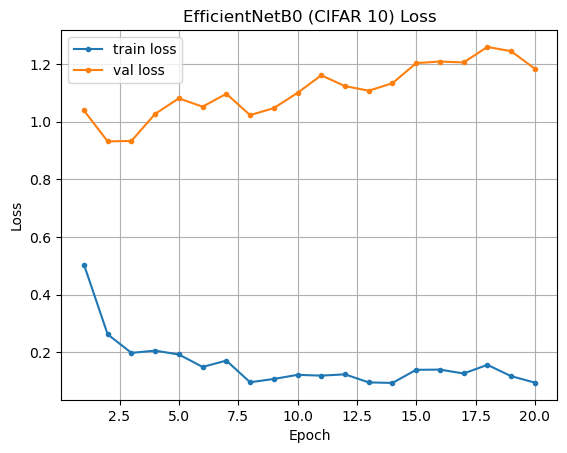

In [79]:
train_loss = [train_log[0] for train_log in train_logs]
val_loss = [val_log[0] for val_log in val_logs]

plot_results([train_loss, val_loss], ['train loss', 'val loss'], 'EfficientNetB0 (CIFAR 10) Loss', 'Epoch', 'Loss')

## Accuracy

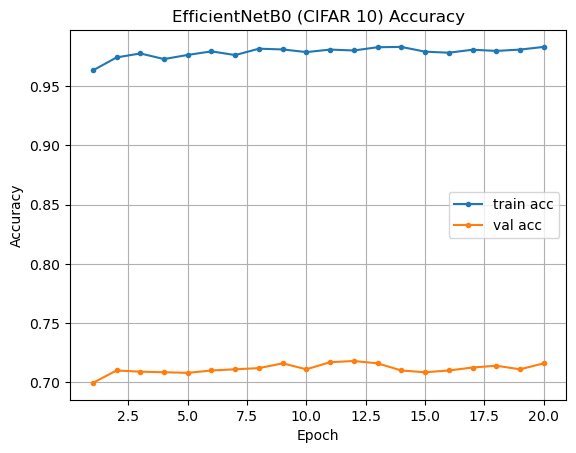

In [80]:
train_acc = [train_log[1] for train_log in train_logs]
val_acc = [val_log[1] for val_log in val_logs]

plot_results([train_acc, val_acc], ['train acc', 'val acc'], 'EfficientNetB0 (CIFAR 10) Accuracy', 'Epoch', 'Accuracy')

## Evalutation on Test dataset

In [81]:
test_loss, test_acc = test_model(trained_model, test_loader, torch.nn.CrossEntropyLoss(), 'cuda')
print(f"Test dataset, Accuracy: {test_acc}, loss: {test_loss}")

Test dataset, Accuracy: 0.6989, loss: 1.1736097475781608


In [82]:
# torch.save(trained_model.cpu().state_dict(), './model_weights/effnet_customized_latent_cp4.pt')